In [119]:
from sklearn.linear_model import Ridge
import numpy as np
from matplotlib import pyplot as plt

In [120]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 1.5 * X**4 + 3.1 * X**3 + 2 * X**2 + X + 2 + np.random.randn(m, 1)

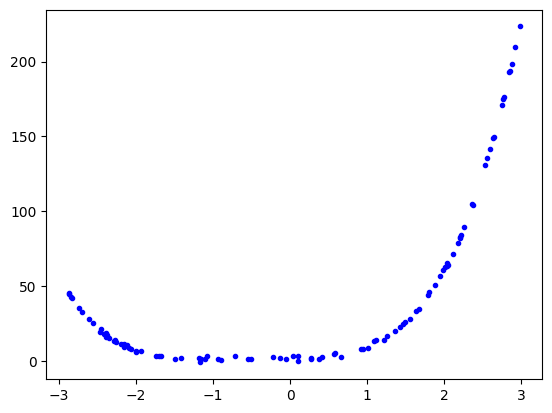

In [121]:
plt.plot(X, y, "b.")

In [122]:
def plot_regression_line(reg, poly_features, range_=(-3, 3)):
    start, end = range_
    X_plot = np.array([i/100 for i in range(start*100, end*100)])
    X_plot = X_plot.reshape(-1, 1)
    X_plot_poly = poly_features.fit_transform(X_plot)
    y_plot = reg.predict(X_plot_poly)
    plt.plot(X_plot, y_plot, "r-")

# Polynomial Features

In [123]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Ridge Regression
## Close-form

In [129]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=2, solver="cholesky")
ridge_reg.fit(X_poly, y.ravel())
ridge_reg.predict(poly_features.fit_transform([[1.5]]))

array([31.15977272])

### Plotting

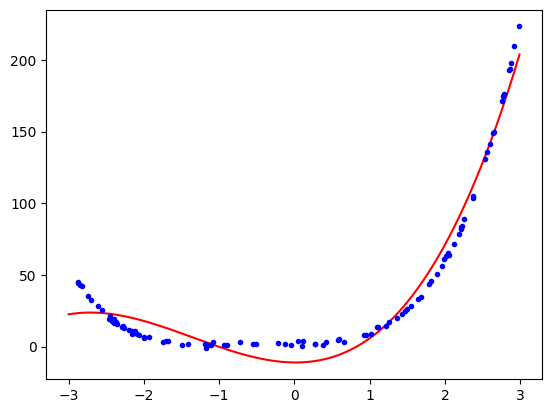

In [130]:
plot_regression_line(ridge_reg, poly_features, (-3, 3))
plt.plot(X, y, "b.")

## Gradient Descent

In [139]:
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(penalty="l2", alpha=1)
sgd_reg.fit(X_poly, y.ravel())
sgd_reg.predict(poly_features.fit_transform([[1.5]]))

array([34.71175297])

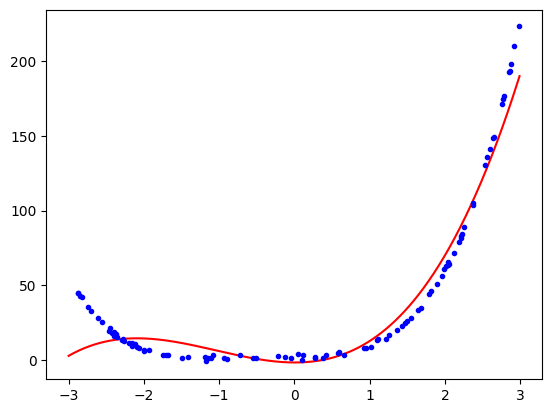

In [140]:
plot_regression_line(sgd_reg, poly_features, (-3, 3))
plt.plot(X, y, "b.")

# Lasso Regression

## Close-form

In [142]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=1)
lasso_reg.fit(X_poly, y.ravel())
lasso_reg.predict(poly_features.fit_transform([[1.5]]))

array([31.68362326])

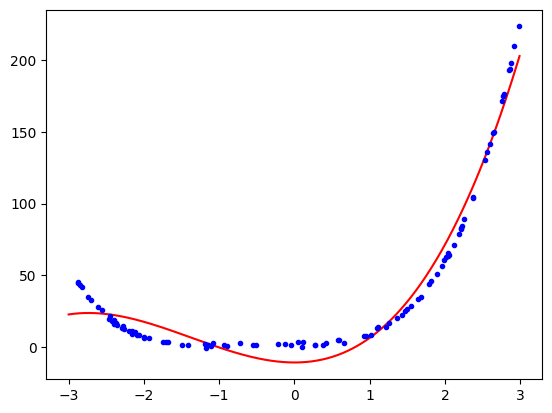

In [143]:
plot_regression_line(lasso_reg, poly_features, (-3, 3))
plt.plot(X, y, "b.")

In [144]:
from sklearn.linear_model import SGDRegressor
lasso_sgd_reg = SGDRegressor(penalty="l1", alpha=1)
lasso_sgd_reg.fit(X_poly, y.ravel())
lasso_sgd_reg.predict(poly_features.fit_transform([[1.5]]))

array([32.48660714])

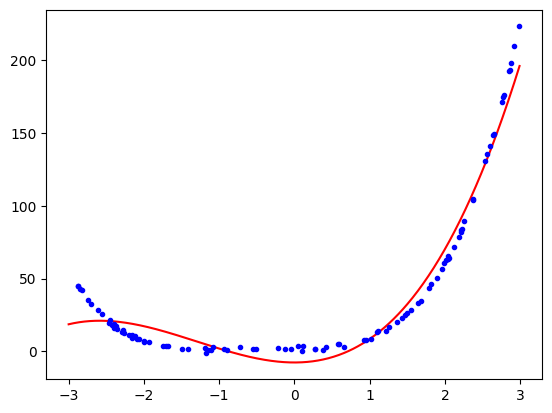

In [145]:
plot_regression_line(lasso_sgd_reg, poly_features, (-3, 3))
plt.plot(X, y, "b.")

# Elastic Net

In [146]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X_poly, y.ravel())
elastic_net.predict(poly_features.fit_transform([[1.5]]))

array([31.39805765])

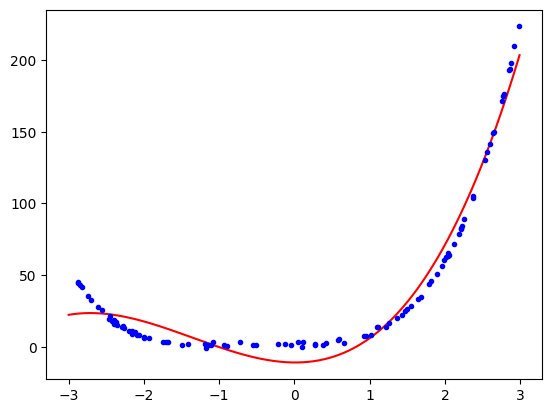

In [147]:
plot_regression_line(elastic_net, poly_features, (-3, 3))
plt.plot(X, y, "b.")

# TODO Early Stopping

In [162]:
from sklearn.base import clone
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# prepare the data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
poly_scaler = Pipeline([
    ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
    ("std_scaler", StandardScaler())
])
X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

In [163]:
# warm_start=True
# when the fit() method is called it continues training
# where it left off, instead of restarting from scratch.
sgd_reg = SGDRegressor(max_iter=1, tol=-np.infty, warm_start=True,
                       penalty=None, learning_rate="constant", eta0=0.0005)
minimum_val_error = float("inf")
best_epoch = None
best_model = None
for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train.ravel()) # continues where it left off
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_predict)
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epoch = epoch
        best_model = clone(sgd_reg)

In [169]:
best_epoch, best_model

(988,
 SGDRegressor(eta0=0.0005, learning_rate='constant', max_iter=1, penalty=None,
              tol=-inf, warm_start=True))